# 05 - Transfer Learning (MobileNetV2)

1. **original** - `data/split`
2. **CLAHE** - `data/enhanced/clahe`
3. **CLAHE + Gaussian** - `data/enhanced/clahe_gaussian`

In [1]:
# ini yang pakai cpu
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

## 1. Import dan Konfigurasi

In [2]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

NUM_THREADS = min(8, os.cpu_count() or 4)
try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError as exc:
    print("Device TensorFlow sudah aktif, konfigurasi :", exc)

try:
    tf.config.threading.set_intra_op_parallelism_threads(NUM_THREADS)
    tf.config.threading.set_inter_op_parallelism_threads(NUM_THREADS)
except RuntimeError as exc:
    print("Threading TensorFlow sudah aktif, konfigurasi :", exc)

IMG_SIZE = (192, 192)
BATCH_SIZE = 10
SEED = 42

EPOCHS_HEAD = 10
DO_FINETUNE = True
EPOCHS_FINETUNE = 5
UNFREEZE_LAST_N = 10

LR_HEAD = 1e-3
LR_FINETUNE = 1e-5

keras.utils.set_random_seed(SEED)

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent

elif (CURRENT_DIR / "data" / "split").exists():
    PROJECT_ROOT = CURRENT_DIR

else:
    PROJECT_ROOT = Path("..").resolve()


DIR_ORIGINAL = PROJECT_ROOT / "data" / "split"

DIR_CLAHE = (
    PROJECT_ROOT
    / "data"
    / "enhanced"
    / "clahe"
)

DIR_CLAHE_GAUSSIAN = (
    PROJECT_ROOT
    / "data"
    / "enhanced"
    / "clahe_gaussian"
)

DIR_MODELS = PROJECT_ROOT / "models"
DIR_METRICS = PROJECT_ROOT / "results" / "metrics"
DIR_FIGURES = PROJECT_ROOT / "results" / "figures"

for d in (DIR_MODELS, DIR_METRICS, DIR_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

EXPECTED_CLASSES = ["biological", "cardboard", "glass", "metal", "paper", "plastic"]
NUM_CLASSES = len(EXPECTED_CLASSES)

print("TensorFlow:", tf.__version__)
print("Physical GPU:", tf.config.list_physical_devices("GPU"))
print("Logical GPU :", tf.config.list_logical_devices("GPU"))
print("Device mode : CPU")
print("CPU threads :", NUM_THREADS)
print("Project root:", PROJECT_ROOT)
print("IMG_SIZE   :", IMG_SIZE)
print("BATCH_SIZE :", BATCH_SIZE)
print("Original Dataset :", DIR_ORIGINAL, "->", DIR_ORIGINAL.exists())
print("CLAHE Dataset    :", DIR_CLAHE, "->", DIR_CLAHE.exists())
print("CLAHE+Gaussian   :", DIR_CLAHE_GAUSSIAN, "->", DIR_CLAHE_GAUSSIAN.exists())

TensorFlow: 2.21.0
Physical GPU: []
Logical GPU : []
Device mode : CPU
CPU threads : 8
Project root: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn
IMG_SIZE   : (192, 192)
BATCH_SIZE : 10
Original Dataset : D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\split -> True
CLAHE Dataset    : D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\enhanced\clahe -> True
CLAHE+Gaussian   : D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\enhanced\clahe_gaussian -> True


## 2. Helper Evaluasi

In [3]:
def compute_metrics(y_true, y_pred):
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "precision_macro": round(float(p_macro), 4),
        "recall_macro": round(float(r_macro), 4),
        "f1_macro": round(float(f_macro), 4),
    }


def plot_confusion(y_true, y_pred, class_names, title, file_name):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(title)
    plt.xlabel("Prediksi")
    plt.ylabel("Label Asli")
    plt.tight_layout()
    path = DIR_FIGURES / file_name
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print("Disimpan:", path)
    return cm


def eval_on_test(model, ds_test):
    y_true, y_pred = [], []
    for xb, yb in ds_test:
        probs = model.predict(xb, verbose=0)
        pred = probs.argmax(axis=1)
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(pred.tolist())
    return np.array(y_true), np.array(y_pred)

## 3. Pipeline Data

In [4]:
def make_datasets(base_dir):
    def load(split, shuffle):
        return keras.utils.image_dataset_from_directory(
            base_dir / split,
            labels="inferred",
            label_mode="int",
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            seed=SEED,
        )

    ds_train = load("train", True)
    ds_val = load("val", False)
    ds_test = load("test", False)

    class_names = ds_train.class_names
    assert class_names == EXPECTED_CLASSES, f"Urutan kelas tidak sesuai: {class_names}"

    options = tf.data.Options()
    options.threading.private_threadpool_size = NUM_THREADS
    options.threading.max_intra_op_parallelism = 1

    ds_train = ds_train.with_options(options).prefetch(1)
    ds_val = ds_val.with_options(options).prefetch(1)
    ds_test = ds_test.with_options(options).prefetch(1)
    return ds_train, ds_val, ds_test, class_names


# ORIGINAL
ds_train_original, ds_val_original, ds_test_original, CLASS_NAMES = \
    make_datasets(DIR_ORIGINAL)

# CLAHE
ds_train_clahe, ds_val_clahe, ds_test_clahe, _ = \
    make_datasets(DIR_CLAHE)

# CLAHE + GAUSSIAN
ds_train_clahe_gaussian, ds_val_clahe_gaussian, ds_test_clahe_gaussian, _ = \
    make_datasets(DIR_CLAHE_GAUSSIAN)

print("Kelas:", CLASS_NAMES)


# Data Augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, seed=SEED),
        layers.RandomZoom(0.05, seed=SEED),
    ],
    name="data_augmentation",
)

Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Kelas: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


In [5]:
# cek apakah ada folder kosong atau jumlah data yg beda
print("\n=== ORIGINAL ===")
print("Train batches:", tf.data.experimental.cardinality(ds_train_original).numpy())
print("Val batches  :", tf.data.experimental.cardinality(ds_val_original).numpy())
print("Test batches :", tf.data.experimental.cardinality(ds_test_original).numpy())

print("\n=== CLAHE ===")
print("Train batches:", tf.data.experimental.cardinality(ds_train_clahe).numpy())
print("Val batches  :", tf.data.experimental.cardinality(ds_val_clahe).numpy())
print("Test batches :", tf.data.experimental.cardinality(ds_test_clahe).numpy())

print("\n=== CLAHE + GAUSSIAN ===")
print("Train batches:", tf.data.experimental.cardinality(ds_train_clahe_gaussian).numpy())
print("Val batches  :", tf.data.experimental.cardinality(ds_val_clahe_gaussian).numpy())
print("Test batches :", tf.data.experimental.cardinality(ds_test_clahe_gaussian).numpy())


=== ORIGINAL ===
Train batches: 540
Val batches  : 116
Test batches : 116

=== CLAHE ===
Train batches: 540
Val batches  : 116
Test batches : 116

=== CLAHE + GAUSSIAN ===
Train batches: 540
Val batches  : 116
Test batches : 116


## 4. Model Transfer Learning

In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


def build_transfer_model():
    keras.utils.set_random_seed(SEED)
    base = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
    )
    base.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = preprocess_input(x)  # Disini ada proses normalisasi yang sesuai dengan MobileNetV2, dari 0-255 ke -1 sampai 1
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="MobileNetV2_CPU")
    model.compile(
        optimizer=keras.optimizers.Adam(LR_HEAD),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model, base


model, base_model = build_transfer_model()
model.summary()

Model: "MobileNetV2_CPU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_192            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Training

In [7]:
HEAD_PATH = DIR_MODELS / "mobilenetv2_head_best.keras"
FINETUNE_PATH = DIR_MODELS / "mobilenetv2_finetune_best.keras"
BEST_PATH = DIR_MODELS / "mobilenetv2_best.keras"


def make_callbacks(path_model, patience=3):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(path_model),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]


def plot_history(histories, title, file_name):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in histories:
        acc.extend(hist.history["accuracy"])
        val_acc.extend(hist.history["val_accuracy"])
        loss.extend(hist.history["loss"])
        val_loss.extend(hist.history["val_loss"])

    epochs = range(1, len(acc) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(epochs, acc, label="train")
    ax[0].plot(epochs, val_acc, label="val")
    ax[0].set_title(f"{title} - Accuracy")
    ax[0].set_xlabel("epoch")
    ax[0].legend()

    ax[1].plot(epochs, loss, label="train")
    ax[1].plot(epochs, val_loss, label="val")
    ax[1].set_title(f"{title} - Loss")
    ax[1].set_xlabel("epoch")
    ax[1].legend()

    if len(histories) > 1:
        boundary = len(histories[0].history["accuracy"]) + 0.5
        for item in ax:
            item.axvline(boundary, color="gray", ls="--", alpha=0.7)

    plt.tight_layout()
    path = DIR_FIGURES / file_name
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print("Disimpan:", path)

### Fungsi untuk ngejalanin eksperimen

In [8]:
def run_experiment(
    scenario_name,
    ds_train,
    ds_val,
    ds_test,
):
    
    print(f"\n{'='*50}")
    print(f"SCENARIO: {scenario_name}")
    print(f"{'='*50}")

    rows = []
    histories = []

    model, base_model = build_transfer_model()

    head_path = DIR_MODELS / f"{scenario_name}_head.keras"
    finetune_path = DIR_MODELS / f"{scenario_name}_finetune.keras"

    # HEAD TRAINING
    history_head = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS_HEAD,
        callbacks=make_callbacks(head_path, patience=3),
        verbose=1,
    )

    histories.append(history_head)

    model_head = (
        keras.models.load_model(head_path)
        if head_path.exists()
        else model
    )

    y_head, pred_head = eval_on_test(
        model_head,
        ds_test,
    )

    m_head = compute_metrics(
        y_head,
        pred_head,
    )

    m_head.update({
        "model": "MobileNetV2",
        "scenario": scenario_name,
        "phase": "head",
    })

    rows.append(m_head)

    # FINETUNE
    if DO_FINETUNE and EPOCHS_FINETUNE > 0:

        model = (
            keras.models.load_model(head_path)
            if head_path.exists()
            else model
        )

        base = next(
            layer
            for layer in model.layers
            if layer.name.startswith("mobilenetv2")
        )

        base.trainable = True

        for layer in base.layers[:-UNFREEZE_LAST_N]:
            layer.trainable = False

        for layer in base.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

        model.compile(
            optimizer=keras.optimizers.Adam(LR_FINETUNE),
            loss=keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"],
        )

        history_ft = model.fit(
            ds_train,
            validation_data=ds_val,
            epochs=EPOCHS_FINETUNE,
            callbacks=make_callbacks(
                finetune_path,
                patience=2,
            ),
            verbose=1,
        )

        histories.append(history_ft)

        model_ft = (
            keras.models.load_model(finetune_path)
            if finetune_path.exists()
            else model
        )

        y_ft, pred_ft = eval_on_test(
            model_ft,
            ds_test,
        )

        m_ft = compute_metrics(
            y_ft,
            pred_ft,
        )

        m_ft.update({
            "model": "MobileNetV2",
            "scenario": scenario_name,
            "phase": "finetune",
        })

        rows.append(m_ft)

    plot_history(
        histories,
        f"MobileNetV2 - {scenario_name}",
        f"history_{scenario_name}.png",
    )

    return pd.DataFrame(rows)

### Lakukan Training untuk Ketiga Skenario Eksperimen


SCENARIO: original
Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 61s 103ms/step - accuracy: 0.7759 - loss: 0.6310 - val_accuracy: 0.8131 - val_loss: 0.4614 - learning_rate: 0.0010
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 51s 95ms/step - accuracy: 0.8610 - loss: 0.3859 - val_accuracy: 0.8512 - val_loss: 0.3941 - learning_rate: 0.0010
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 51s 94ms/step - accuracy: 0.8892 - loss: 0.3050 - val_accuracy: 0.8659 - val_loss: 0.3504 - learning_rate: 0.0010
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 51s 94ms/step - accuracy: 0.9025 - loss: 0.2640 - val_accuracy: 0.8754 - val_loss: 0.3407 - learning_rate: 0.0010
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 52s 97ms/step - accuracy: 0.9135 - loss: 0.2300 - val_accuracy: 0.8694 - val_loss: 0.3235 - learning_rate: 0.0010
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9172 - loss: 0.2247
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
540/540 ━━━━━━━━━━━━━━━━━━━━ 114s 157ms/step 

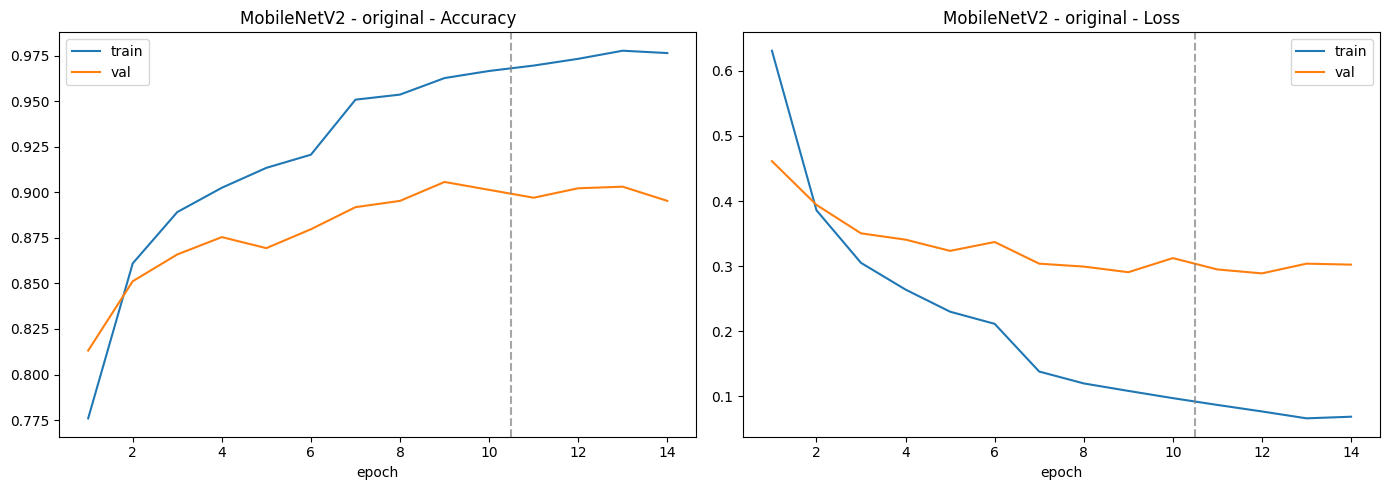

Disimpan: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\results\figures\history_original.png


In [9]:
# Eksperimen 1: ORIGINAL
results_original = run_experiment(
    "original",
    ds_train_original,
    ds_val_original,
    ds_test_original,
)


SCENARIO: clahe
Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 113s 195ms/step - accuracy: 0.7556 - loss: 0.6760 - val_accuracy: 0.8218 - val_loss: 0.4904 - learning_rate: 0.0010
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 494s 916ms/step - accuracy: 0.8530 - loss: 0.4098 - val_accuracy: 0.8382 - val_loss: 0.4251 - learning_rate: 0.0010
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 92s 170ms/step - accuracy: 0.8807 - loss: 0.3250 - val_accuracy: 0.8720 - val_loss: 0.3632 - learning_rate: 0.0010
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.8950 - loss: 0.2858
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
540/540 ━━━━━━━━━━━━━━━━━━━━ 91s 168ms/step - accuracy: 0.8960 - loss: 0.2810 - val_accuracy: 0.8460 - val_loss: 0.4256 - learning_rate: 0.0010
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 130s 241ms/step - accuracy: 0.9216 - loss: 0.2115 - val_accuracy: 0.8720 - val_loss: 0.3522 - learning_rate: 5.0000e-04
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 146s 270

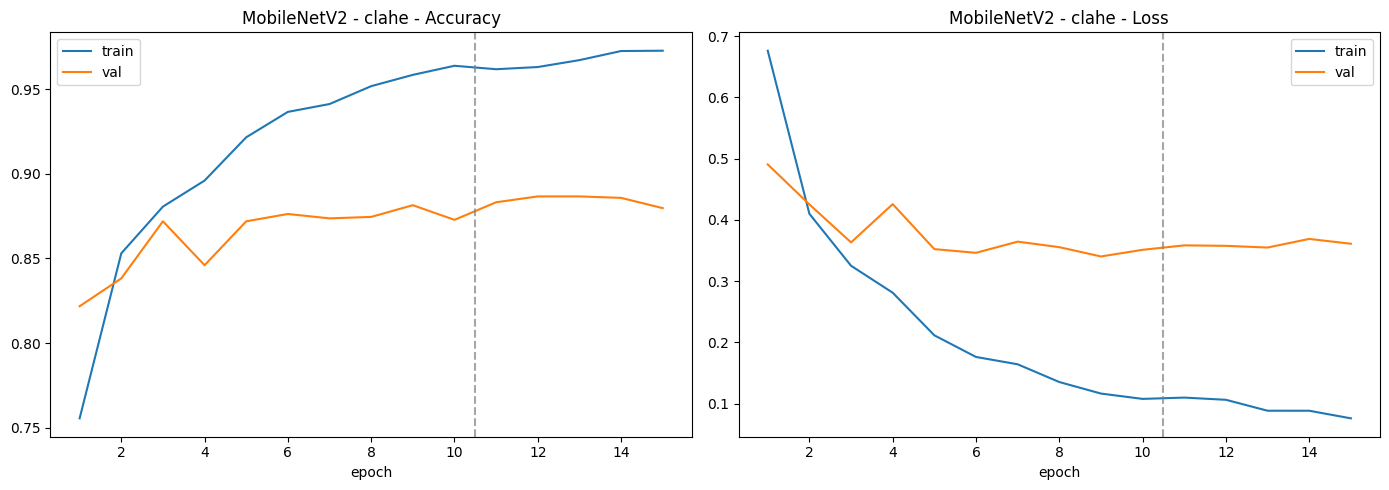

Disimpan: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\results\figures\history_clahe.png


In [10]:
# Eksperimen 2: CLAHE
results_clahe = run_experiment(
    "clahe",
    ds_train_clahe,
    ds_val_clahe,
    ds_test_clahe,
)


SCENARIO: clahe_gaussian
Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 70s 120ms/step - accuracy: 0.7570 - loss: 0.6713 - val_accuracy: 0.8356 - val_loss: 0.4614 - learning_rate: 0.0010
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 55s 102ms/step - accuracy: 0.8497 - loss: 0.4090 - val_accuracy: 0.8521 - val_loss: 0.4009 - learning_rate: 0.0010
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 53s 98ms/step - accuracy: 0.8760 - loss: 0.3228 - val_accuracy: 0.8659 - val_loss: 0.3844 - learning_rate: 0.0010
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8915 - loss: 0.2947
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
540/540 ━━━━━━━━━━━━━━━━━━━━ 105s 194ms/step - accuracy: 0.8951 - loss: 0.2821 - val_accuracy: 0.8590 - val_loss: 0.4048 - learning_rate: 0.0010
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 164s 235ms/step - accuracy: 0.9240 - loss: 0.2056 - val_accuracy: 0.8702 - val_loss: 0.3608 - learning_rate: 5.0000e-04
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2

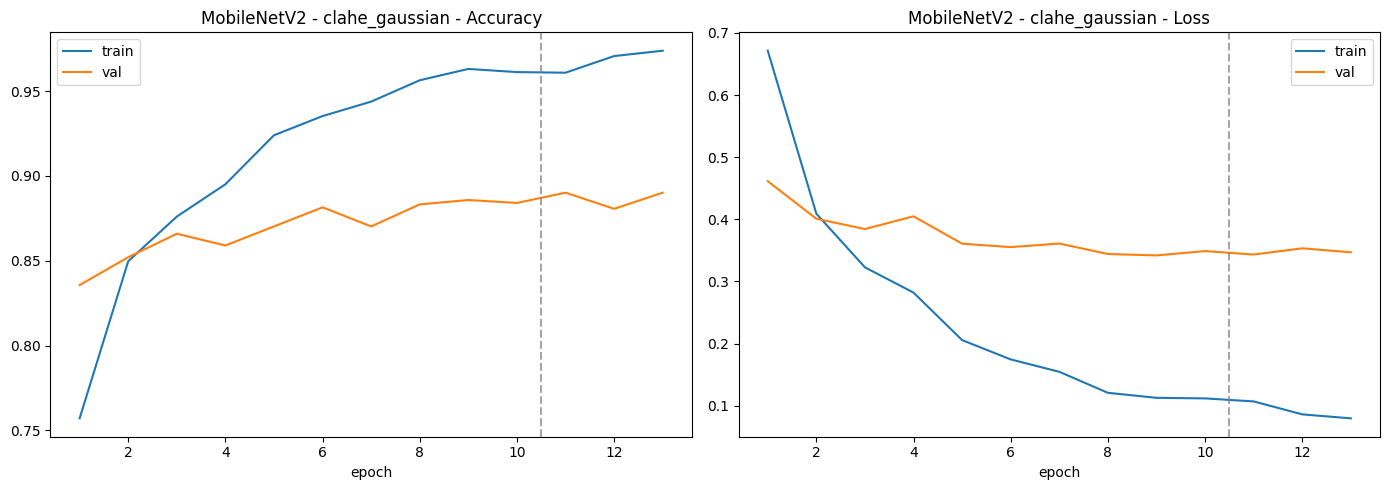

Disimpan: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\results\figures\history_clahe_gaussian.png


In [11]:
# Eksperimen 3: CLAHE + GAUSSIAN
results_clahe_gaussian = run_experiment(
    "clahe_gaussian",
    ds_train_clahe_gaussian,
    ds_val_clahe_gaussian,
    ds_test_clahe_gaussian,
)

In [12]:
results_all = pd.concat(
    [
        results_original,
        results_clahe,
        results_clahe_gaussian,
    ],
    ignore_index=True,
)

display(results_all)

,accuracy,precision_macro,recall_macro,f1_macro,model,scenario,phase
0,0.8902,0.8969,0.8989,0.8968,MobileNetV2,original,head
1,0.9006,0.9057,0.9067,0.9054,MobileNetV2,original,finetune
2,0.8799,0.8863,0.8885,0.8861,MobileNetV2,clahe,head
3,0.8850,0.8889,0.8929,0.8896,MobileNetV2,clahe,finetune
4,0.8799,0.8858,0.8883,0.8859,MobileNetV2,clahe_gaussian,head
5,0.8885,0.8946,0.8951,0.8945,MobileNetV2,clahe_gaussian,finetune


In [13]:
results_all.to_csv(
    DIR_METRICS / "cnn_mobilenetv2_results.csv",
    index=False,
)

## 6. Evaluasi dan Simpan Hasil

In [14]:
# load model terbaik tiap skenario untuk plot confusion matrix
model_original = keras.models.load_model(
    DIR_MODELS / "original_finetune.keras"
)

model_clahe = keras.models.load_model(
    DIR_MODELS / "clahe_finetune.keras"
)

model_clahe_gaussian = keras.models.load_model(
    DIR_MODELS / "clahe_gaussian_finetune.keras"
)

In [15]:
# generate y_true dan y_pred untuk masing-masing model dan dataset testnya
y_true_ori, y_pred_ori = eval_on_test(
    model_original,
    ds_test_original
)

y_true_clahe, y_pred_clahe = eval_on_test(
    model_clahe,
    ds_test_clahe
)

y_true_cg, y_pred_cg = eval_on_test(
    model_clahe_gaussian,
    ds_test_clahe_gaussian
)

In [16]:
# plot perbandingan confusion matrix
from sklearn.metrics import confusion_matrix

def plot_confusion_comparison(
    y_true_ori,
    y_pred_ori,
    y_true_clahe,
    y_pred_clahe,
    y_true_cg,
    y_pred_cg,
    class_names,
):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(22,6)
    )

    scenarios = [
        (y_true_ori, y_pred_ori, "Original"),
        (y_true_clahe, y_pred_clahe, "CLAHE"),
        (y_true_cg, y_pred_cg, "CLAHE + Gaussian"),
    ]

    for ax, (yt, yp, title) in zip(
        axes,
        scenarios
    ):

        cm = confusion_matrix(
            yt,
            yp,
            labels=range(len(class_names))
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax,
        )

        ax.set_title(title)
        ax.set_xlabel("Prediksi")
        ax.set_ylabel("Label Asli")

    plt.tight_layout()
    plt.show()

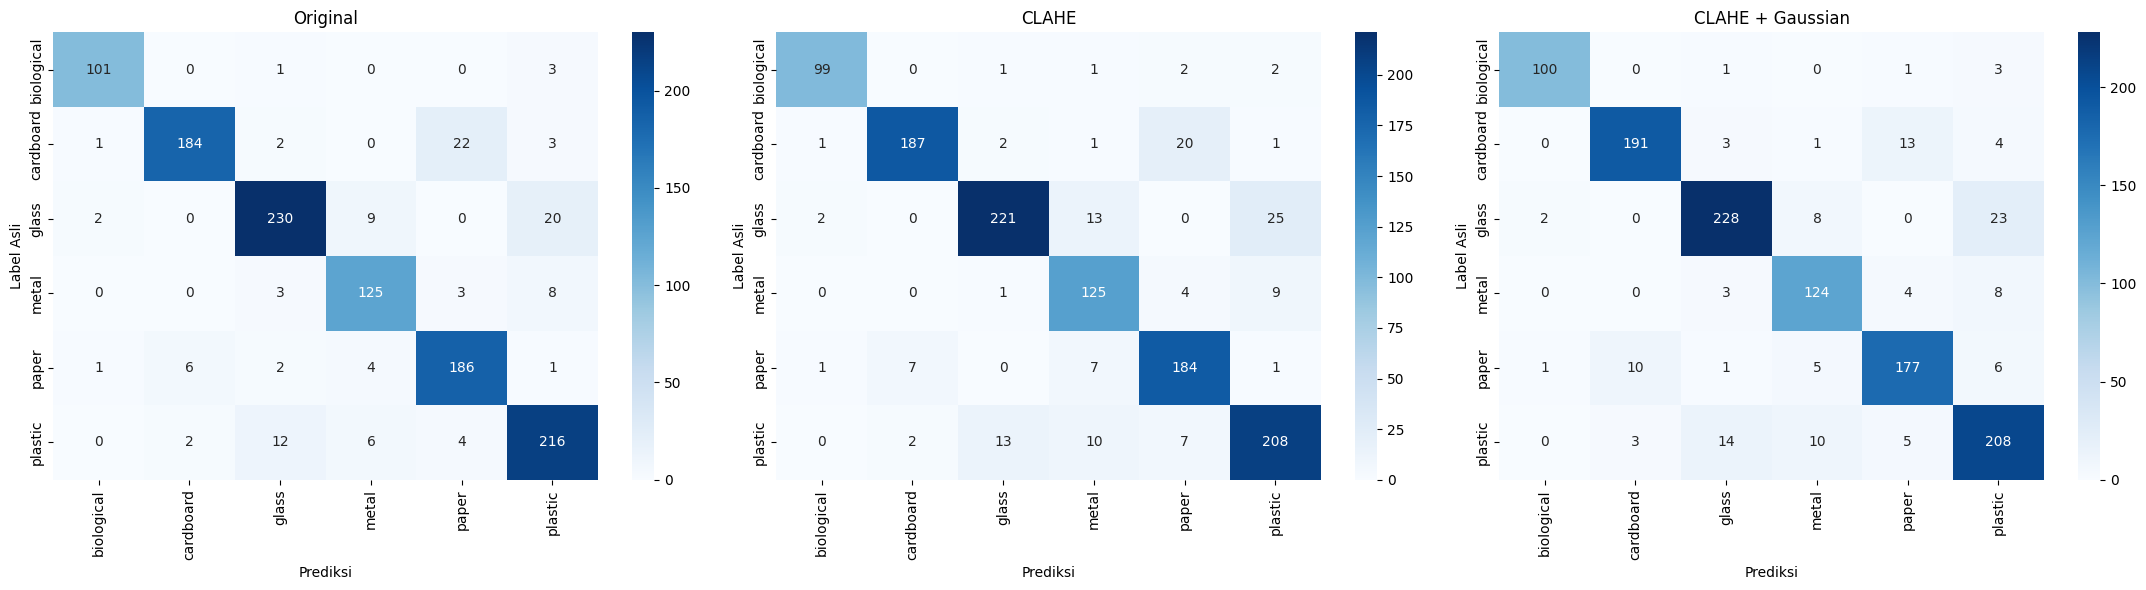

In [17]:
plot_confusion_comparison(
    y_true_ori,
    y_pred_ori,
    y_true_clahe,
    y_pred_clahe,
    y_true_cg,
    y_pred_cg,
    CLASS_NAMES
)